In [24]:
# Step 1: Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Step 2: Load the dataset
df = pd.read_csv("C:\\Disk Partition\\Jupyter\\car_parts_sales.csv")

In [5]:
df.head()

,order_id,order_date,customer_id,customer_name,product_category,product_name,product_price,quantity,total_amount,payment_method
0,10001,2026-05-03,2410,Kyle Bishop,Engine Parts,Oil Filter,2482.20,7,17375.40,Card
1,10002,2026-03-30,9234,Ricky Scott,Engine Parts,Timing Belt,3363.12,1,3363.12,Card
2,10003,2026-04-25,1342,Donald Sosa,Interior,Seat Cover,1436.42,7,10054.94,COD
3,10004,2025-12-11,4417,Eric Bradford,Interior,Floor Mat,3276.09,10,32760.90,COD
4,10005,2026-08-08,3207,Adam Hall,Suspension,Coil Spring,2789.51,7,19526.57,Wallet


In [29]:
# Summary statistics for numerical columns
df.describe()

,order_id,customer_id,product_price,quantity,total_amount
count,100.000000,100.00000,100.000000,100.0000,100.000000
mean,10050.500000,5490.96000,2912.279500,5.5200,15825.992200
std,29.011492,2557.23316,1293.199161,2.6911,11120.900716
min,10001.000000,1055.00000,625.260000,1.0000,1992.390000
25%,10025.750000,3451.00000,1780.497500,3.0000,6532.420000
50%,10050.500000,5442.00000,3000.370000,5.5000,13306.760000
75%,10075.250000,7583.50000,4031.905000,8.0000,22798.752500
max,10100.000000,9838.00000,4993.850000,10.0000,48744.600000


In [30]:
# Check structure of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          100 non-null    int64  
 1   order_date        100 non-null    str    
 2   customer_id       100 non-null    int64  
 3   customer_name     100 non-null    str    
 4   product_category  100 non-null    str    
 5   product_name      100 non-null    str    
 6   product_price     100 non-null    float64
 7   quantity          100 non-null    int64  
 8   total_amount      100 non-null    float64
 9   payment_method    100 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 7.9 KB


In [11]:
# Count unique values in product category column
df['product_category'].value_counts()

product_category
Electrical      27
Engine Parts    25
Suspension      22
Interior        17
Brake System     9
Name: count, dtype: int64

In [12]:
# Count unique values in payment method column
df['payment_method'].value_counts()

payment_method
Wallet    27
UPI       26
Card      25
COD       22
Name: count, dtype: int64

### Observation 1
**Correlations:** Strong positive correlation between quantity and total_amount (expected), moderate correlation between product_price and total_amount

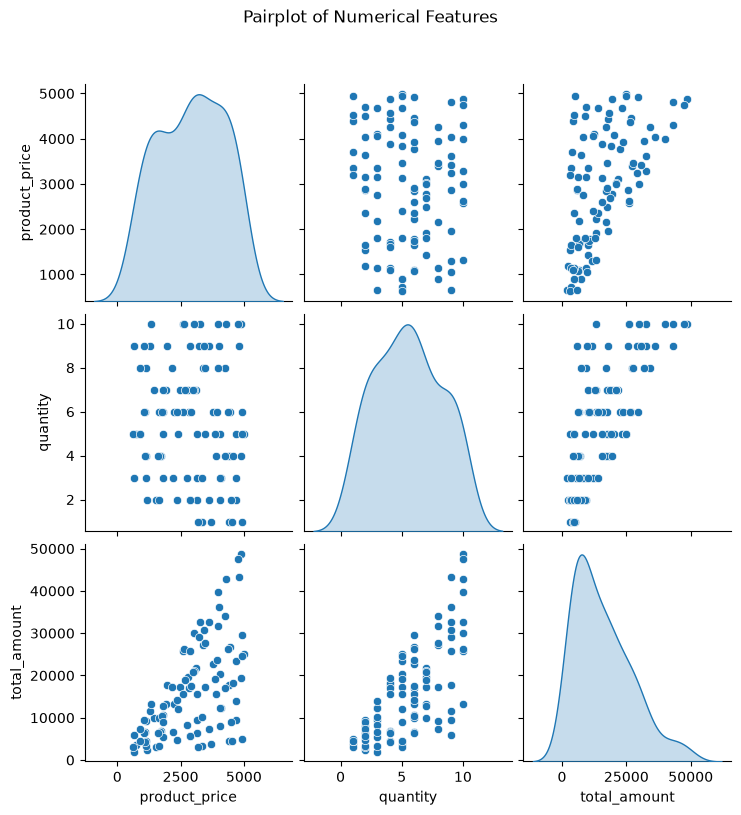

In [36]:
# Pairplot for numerical features
sns.pairplot(df[['product_price','quantity','total_amount']], diag_kind='kde')
plt.suptitle("Pairplot of Numerical Features", y=1.08)
plt.show()

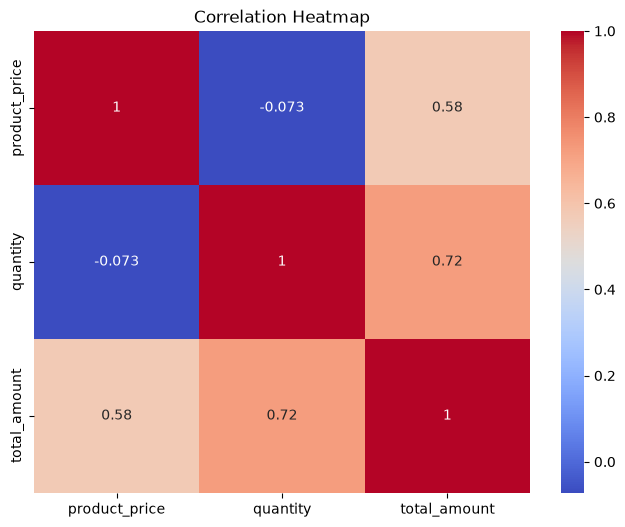

In [31]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['product_price','quantity','total_amount']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Observation 2:
**Price Distribution:** Most products are priced between ₹1,000–₹5,000, with a few values significantly higher than others.

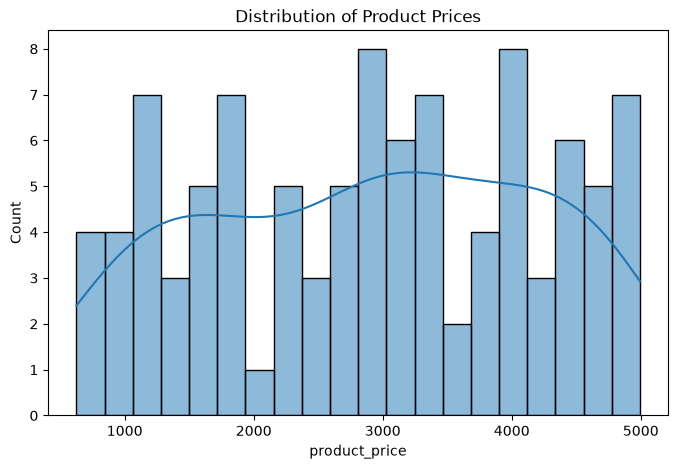

In [37]:
# Histogram of product prices
plt.figure(figsize=(8,5))
sns.histplot(df['product_price'], bins=20, kde=True)
plt.title("Distribution of Product Prices")
plt.show()

### Observation 3
**Total Amount:** Some very large transactions (₹40k+) suggest bulk purchases

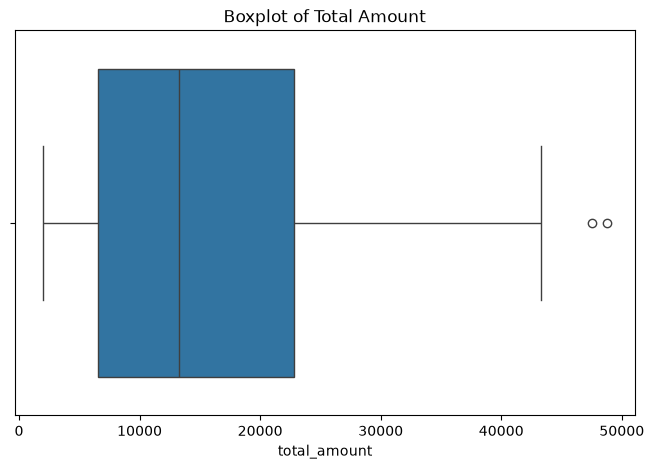

In [41]:
# Boxplot of total amount
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_amount'])
plt.title("Boxplot of Total Amount")
plt.show()

### Observation 4
**Payment Methods:** Wallet and COD are common, but high‑value purchases lean toward Card/UPI.

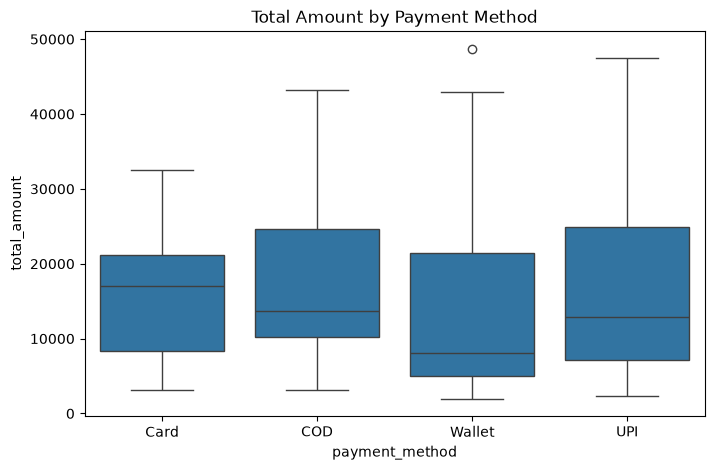

In [38]:
# Boxplot: total amount by payment method
plt.figure(figsize=(8,5))
sns.boxplot(x='payment_method', y='total_amount', data=df)
plt.title("Total Amount by Payment Method")
plt.show()

### Observation 5
**Category Trends:** Suspension and Electrical parts often have higher transaction totals.

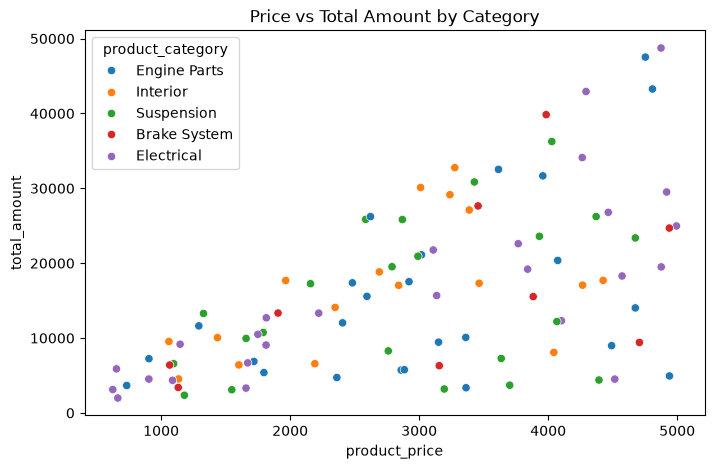

In [39]:
# Scatterplot: product price vs total amount
plt.figure(figsize=(8,5))
sns.scatterplot(x='product_price', y='total_amount', data=df, hue='product_category')
plt.title("Price vs Total Amount by Category")
plt.show()

### 8. Summary of Findings
- **Top Categories:** Electrical and Engine parts dominate sales volume with 50.5% of total sales.
- **High‑Value Customers:** Large purchases are concentrated in Brake System and Engine Parts.  
- **Payment Insights:** Wallet is popular for mid‑range purchases, while Card/UPI are used for higher amounts.  
- **Outliers:** A few extreme transactions may need further investigation (possible bulk orders or anomalies).